In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json()

cp: cannot stat 'kaggle.json': No such file or directory
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `chmod 600 ~/.kaggle/kaggle.json()'


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpImage
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
with_mask_files = os.listdir('/kaggle/input/face-mask-dataset/data/with_mask')
without_mask_files = os.listdir('/kaggle/input/face-mask-dataset/data/without_mask')

In [ ]:
len(with_mask_files)

3725

In [ ]:
len(without_mask_files)

3828

# Creating labels for two classes of images

In [ ]:
# with mask -> 1, without mask -> 0

with_mask_labels = [1]*3725
without_mask_labels = [0]*3828
labels = with_mask_labels + without_mask_labels

In [ ]:
len(labels)

7553

# Displaying images

In [ ]:
with_mask_path = '/kaggle/input/face-mask-dataset/data/with_mask/'
without_mask_path = '/kaggle/input/face-mask-dataset/data/without_mask/'

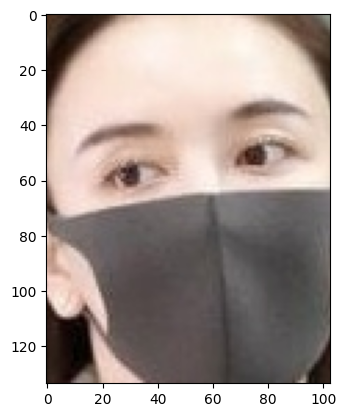

In [ ]:
img = mpImage.imread(f'{with_mask_path}{with_mask_files[22]}')
implot = plt.imshow(img)
plt.show()

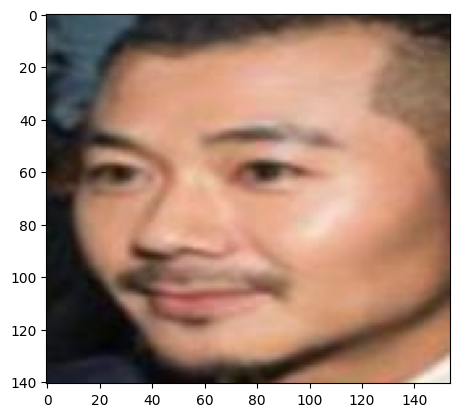

In [ ]:
img = mpImage.imread(f'{without_mask_path}{without_mask_files[22]}')
implot = plt.imshow(img)
plt.show()

# Image Processing

In [ ]:
# resizing the images
# convert the images to numpy arrya

data = []
for img in with_mask_files:
  image = Image.open(with_mask_path + img)
  image = image.resize((128, 128))
  image = image.convert('RGB')

  image = np.array(image)
  data.append(image)

for img in without_mask_files:
  image = Image.open(without_mask_path + img)
  image = image.resize((128, 128))
  image = image.convert('RGB')

  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
len(data)

7553

In [ ]:
X = np.array(data)
Y = np.array(labels)

In [ ]:
X.shape

(7553, 128, 128, 3)

In [ ]:
device = torch.device('cuda')

In [ ]:
Y.shape

(7553,)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(6042, 128, 128, 3)
(1511, 128, 128, 3)


# Converting to tensor and Loading tensor

In [ ]:
x_train_scaled = X_train / 255
x_test_scaled = X_test / 255

x_train_tensor = torch.tensor(x_train_scaled, dtype = torch.float32).permute(0,3,1,2)
x_test_tensor = torch.tensor(x_test_scaled, dtype = torch.float32).permute(0,3,1,2)

y_train_tensor = torch.tensor(Y_train, dtype = torch.long)
y_test_tensor = torch.tensor(Y_test, dtype = torch.long)

In [ ]:
train_set = TensorDataset(x_train_tensor, y_train_tensor)
test_set = TensorDataset(x_test_tensor, y_test_tensor)

In [ ]:
train_loader = DataLoader(train_set, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_set, batch_size = 32)

In [ ]:
print('X_train.shape', X_train.shape)
print('X_test.shape', X_test.shape)
print('Y_train.shape', Y_train.shape)
print('Y_test.shape', Y_test.shape)

X_train.shape (6042, 128, 128, 3)
X_test.shape (1511, 128, 128, 3)
Y_train.shape (6042,)
Y_test.shape (1511,)


# Creating model

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    self.cnn = nn.Sequential(

        nn.Conv2d(3, 32, kernel_size=(3,3), padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),

        nn.Conv2d(32, 64, kernel_size=(3,3), padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),

        nn.Conv2d(64, 128, kernel_size=(3,3), padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),
    )

    self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(16*16*128, 256),
        nn.ReLU(),

        nn.Linear(256, 1)

    )


  def forward(self, x):
    x = self.cnn(x)
    x = self.fc(x)

    return x

In [ ]:
model = CNN()
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

# Training

In [ ]:
epochs = 10

epochs = 10

for epoch in range(epochs):

    model.train()
    running_train_loss = 0

    for image, label in train_loader:

        image = image.to(device)
        label = label.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        output = model(image)

        loss = criterion(output, label)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    model.eval()

    running_test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for image, label in test_loader:

            image = image.to(device)
            label = label.float().unsqueeze(1).to(device)

            output = model(image)

            loss = criterion(output, label)

            pred = (torch.sigmoid(output) > 0.5).float()
            running_test_loss += loss.item()
            correct += (pred == label).sum().item()
            total += label.size(0)

    print(f'epoch {epoch + 1}/{epochs} train loss = {running_train_loss/len(train_loader)}, test loss = {running_test_loss/len(test_loader)} and accuracy = {correct/total}')

epoch 1/10 train loss = 0.3539628251677468, test loss = 0.24539047138144574 and accuracy = 0.900066181336863
epoch 2/10 train loss = 0.2414992185674174, test loss = 0.22626268429060778 and accuracy = 0.9099933818663137
epoch 3/10 train loss = 0.18431225809313, test loss = 0.17657739024434704 and accuracy = 0.9344804765056254
epoch 4/10 train loss = 0.14468700657031996, test loss = 0.17218572944208668 and accuracy = 0.9384513567174056
epoch 5/10 train loss = 0.14395016802366448, test loss = 0.21103234745775504 and accuracy = 0.9245532759761748
epoch 6/10 train loss = 0.09490108067199352, test loss = 0.17037119739688933 and accuracy = 0.9397749834546658
epoch 7/10 train loss = 0.0677910888365534, test loss = 0.19598644302459434 and accuracy = 0.9344804765056254
epoch 8/10 train loss = 0.051204729048540155, test loss = 0.19949493506336088 and accuracy = 0.9563203176704169
epoch 9/10 train loss = 0.0367159438282547, test loss = 0.23758394881345643 and accuracy = 0.9364659166115156
epoch 10

In [ ]:
 torch.save(model.state_dict(), 'face_mask_best.pt')

In [ ]:
model.load_state_dict(torch.load('face_mask_best.pt'))

<All keys matched successfully>

In [ ]:
model.eval()

for image, label in test_loader:

    image = image.to(device)
    label = label.float().unsqueeze(1).to(device)

    output = model(image)

    loss = criterion(output, label)

    pred = (torch.sigmoid(output) > 0.5).float()
    running_test_loss += loss.item()
    correct += (pred == label).sum().item()
    total += label.size(0)

print('accuracy:', correct/total)


accuracy: 0.9510258107213766


In [ ]:
model.eval()

for image, label in train_loader:

    image = image.to(device)
    label = label.float().unsqueeze(1).to(device)

    output = model(image)

    loss = criterion(output, label)

    pred = (torch.sigmoid(output) > 0.5).float()
    running_test_loss += loss.item()
    correct += (pred == label).sum().item()
    total += label.size(0)

print('accuracy:', correct/total)

accuracy: 0.9817961165048543
